# Regression de la note donnée à un vin

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd


Première visualisation des données

In [4]:
df = pd.read_csv("data/winemag-data-130k-v2.csv")
print("nombre d'entrée: "+str(df.shape[0]) + "| nombre de charactéristiques: " +str(df.shape[1]))
print("nom des charactéristiques: "+ str(df.columns))

nombre d'entrée: 129971| nombre de charactéristiques: 14
nom des charactéristiques: Index(['id', 'country', 'description', 'designation', 'points', 'price',
       'province', 'region_1', 'region_2', 'taster_name',
       'taster_twitter_handle', 'title', 'variety', 'winery'],
      dtype='str')


In [69]:
NB_COUNTRY = 10
NB_PROVINCE = 10
NB_VARIETY = 10
NB_PRODUCER = 10

MIN_COUNTRY = df['country'].value_counts().iloc[NB_COUNTRY - 1]
MIN_PROVINCE = df['province'].value_counts().iloc[NB_PROVINCE - 1]
MIN_VARIETY = df['variety'].value_counts().iloc[NB_VARIETY - 1]
MIN_PRODUCER = df['winery'].value_counts().iloc[NB_PRODUCER - 1]

Nombre de lignes correspondant aux pays rares : 5324


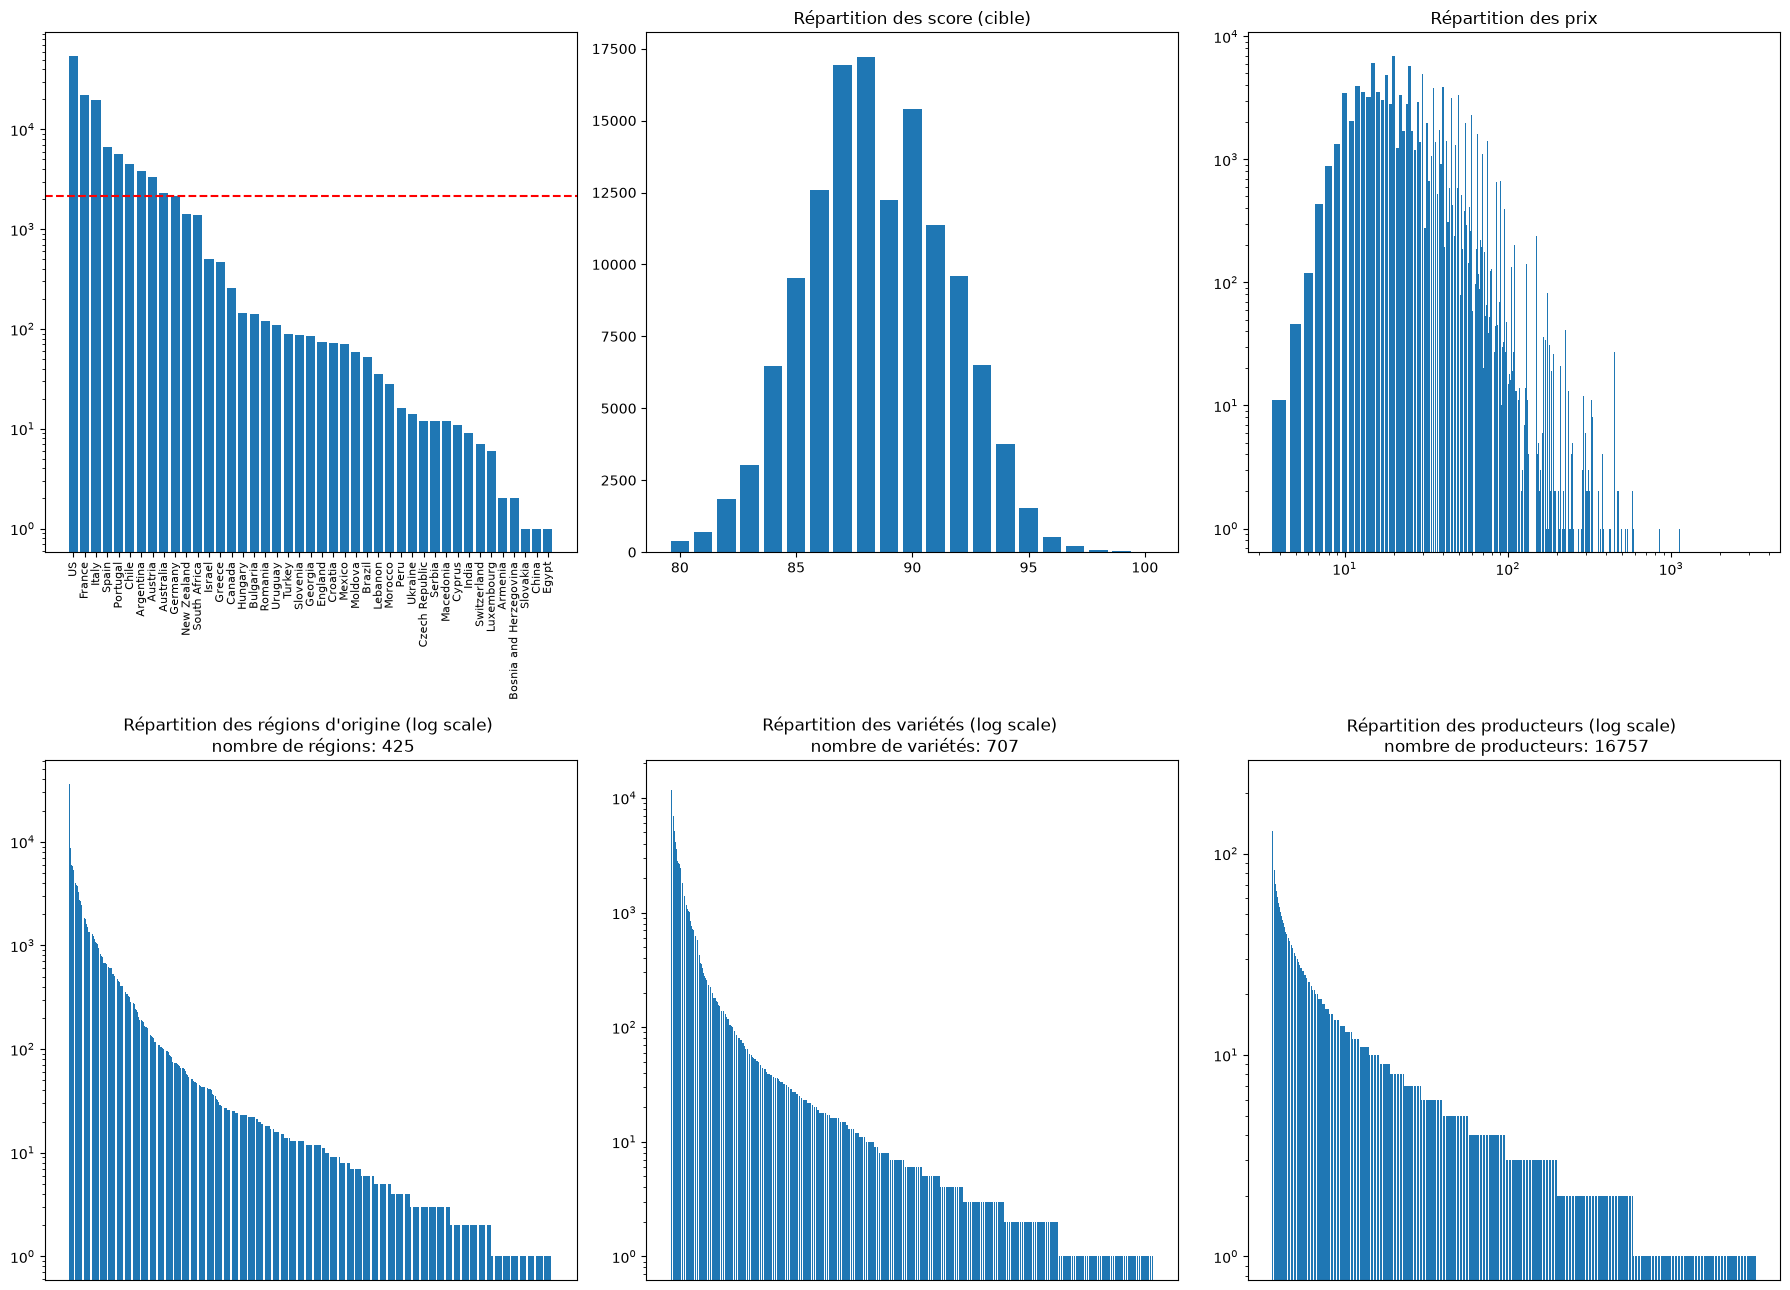

In [71]:
plt.figure(figsize=(18,13))

plt.subplot(2,3,1)
plt.bar(df['country'].value_counts().index, df['country'].value_counts())
plt.yscale("log")
plt.xticks(rotation=90, fontsize=8)
plt.axhline(
    y=MIN_COUNTRY,
    color='red',
    linestyle='--'
)
nb_lignes_pays_rares = df['country'].value_counts().loc[lambda counts: counts < MIN_COUNTRY].sum()
print("Nombre de lignes correspondant aux pays rares :", nb_lignes_pays_rares)

plt.subplot(2,3,2)
plt.bar(df['points'].value_counts().index, df['points'].value_counts())
plt.title("Répartition des score (cible)")

plt.subplot(2,3,3)
plt.bar(df['price'].value_counts().index, df['price'].value_counts())
plt.title("Répartition des prix")
plt.yscale("log")
plt.xscale("log")

plt.subplot(2,3,4)
plt.bar(df['province'].value_counts().index, df['province'].value_counts())
plt.yscale("log")
plt.title("Répartition des régions d'origine (log scale) \n nombre de régions: " + str(df['province'].nunique()))
plt.xticks([])

plt.subplot(2,3,5)
plt.bar(df['variety'].value_counts().index, df['variety'].value_counts())
plt.yscale("log")
plt.title("Répartition des variétés (log scale) \n nombre de variétés: " + str(df['variety'].nunique()))
plt.xticks([])

plt.subplot(2,3,6)
plt.bar(df['winery'].value_counts().index, df['winery'].value_counts())
plt.yscale("log")
plt.title("Répartition des producteurs (log scale) \n nombre de producteurs: " + str(df['winery'].nunique()))
plt.xticks([])

plt.tight_layout()





In [62]:
print("charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques")

for s in df.columns:
    print("< " + s + " >  | " + str(df[s].isna().sum()) + " | " + str(round(df[s].isna().sum()/df.shape[0]*100, 2)) + "% | " + str(df[s].nunique()))



charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques
< id >  | 0 | 0.0% | 129971
< country >  | 63 | 0.05% | 43
< description >  | 0 | 0.0% | 119955
< designation >  | 37465 | 28.83% | 37976
< points >  | 0 | 0.0% | 21
< price >  | 8996 | 6.92% | 390
< province >  | 63 | 0.05% | 425
< region_1 >  | 21247 | 16.35% | 1229
< region_2 >  | 79460 | 61.14% | 17
< taster_name >  | 26244 | 20.19% | 19
< taster_twitter_handle >  | 31213 | 24.02% | 15
< title >  | 0 | 0.0% | 118840
< variety >  | 1 | 0.0% | 707
< winery >  | 0 | 0.0% | 16757


"taster_twitter_handle" est inutile ici
<br>La désignation présente trop de valeur vide + trop différentes.
<br>"title" est le nom du vin, trop de valeurs différentes ici
<br>On garde l'id pour numéroter les données dans le dataframe (pas donné au modèle)

In [64]:
df = df.drop(columns=['designation', 'taster_twitter_handle', 'title'])

On va regrouper les valeur de charactéristiques les plus rares et remplacer les valeurs manquantes:

In [ ]:
z